In [ ]:
# torch.tensor <-> pandas.dataframe
# networkx graph construction
# torch.bincount = counting the degree of each node
# bincount(x, minlength) -> minlength: the minimum length of the output tensor, starting from 0 to minlength-1. If minlength is not provided, the output tensor will have a length of max(x) + 1, where max(x) is the maximum value in the input tensor x.

# !! As bincount must start from 0, we need to define all nodes from 0 to max node index, even if some nodes have no edges. This ensures that the output tensor has the correct length and includes counts for all nodes up to the maximum index.
# !! If the edges list represents an undirected graph, the bincount() will count the out-degree (same as in-degree)of each node, which is the number of outgoing edges from that node.

Edges tensor:
 tensor([[1, 0, 2, 0, 3, 0],
        [0, 1, 0, 2, 0, 3]])
Shape of edges tensor: torch.Size([2, 6])
   row  col
0    1    0
1    0    1
2    2    0
3    0    2
4    3    0
5    0    3
Nodes in the graph: [1, 0, 2, 3]
Edges in the graph: [(1, 0), (0, 1), (0, 2), (0, 3), (2, 0), (3, 0)]


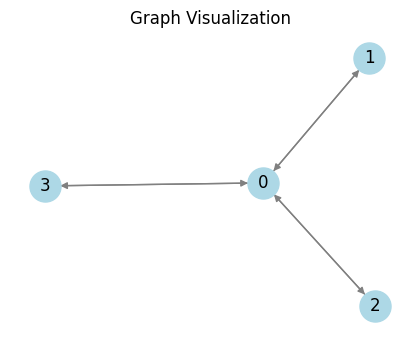

Row tensor: tensor([1, 0, 2, 0, 3, 0])
counts: tensor([3, 1, 1, 1])


In [24]:
import torch
import networkx as nx
import pandas as pd 
import matplotlib.pyplot as plt


#edges = torch.tensor([[1, 1, 2, 3],            # asymmetic graph, node 0 has no outgoing edges, but has incoming edge from node 1
 #                     [0, 2, 0, 0]])

edges = torch.tensor([[1, 0, 2, 0, 3, 0],             # undirected graph, node 0 has outgoing edge to node 1 and node 2, node 1 has outgoing edge to node 0, node 2 has outgoing edge to node 0, node 3 has no edges           
                      [0, 1, 0, 2, 0, 3]])
print("Edges tensor:\n", edges) 
print("Shape of edges tensor:", edges.shape)  # Should be (2, number_of_edges)

df_edges = pd.DataFrame(edges.t().numpy(), columns=['row', 'col'])    
print(df_edges)


G = nx.from_pandas_edgelist(df_edges, 'row', 'col', create_using=nx.DiGraph())
print("Nodes in the graph:", G.nodes())
print("Edges in the graph:", G.edges())

plt.figure(figsize=(4, 3))   # (8, 6)
nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=12)
plt.title("Graph Visualization")
plt.show()      


row, col = edges
# bincount returns counts for each integer value from 0 to max(x)
counts = torch.bincount(row, minlength=row.max().item() + 1) # explicitly set minlength to ensure we get counts for all nodes up to the maximum index

print("Row tensor:", row)
print("counts:", counts)


In [23]:
dim = torch.tensor([5,3])
print("dim:", dim.size(0))




dim: 2
